# Filtragem convolucional

Nesta lição, vamos exercitar os filtros lineares usando convolução.

A ideia é que você modifique estes exemplos para rodar com as suas imagens. Experimente outros kernels.


In [23]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color, img_as_float
from skimage.util import img_as_ubyte, random_noise
from skimage.filters import prewitt_h, prewitt_v, roberts, gaussian
from skimage.filters.thresholding import threshold_otsu
from scipy.signal import convolve2d

def normalize01(x):
    x = x.astype(np.float64)
    x = x - x.min()
    if x.max() > 0:
        x = x / x.max()
    return x

def grad_magnitude(gx, gy):
    return np.sqrt(gx**2 + gy**2)

def show_images(imgs, titles=None, cmap=None, figsize=(14, 6)):
    """Utility to visualize one row of images."""
    n = len(imgs)
    if titles is None:
        titles = ["" for _ in range(n)]
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(imgs, titles), start=1):
        plt.subplot(1, n, i)
        if im.ndim == 2:
            plt.imshow(im, cmap=cmap if cmap else 'gray')
        else:
            plt.imshow(im)
        plt.title(t)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [2]:
camera = img_as_float(data.camera())

## Convolução

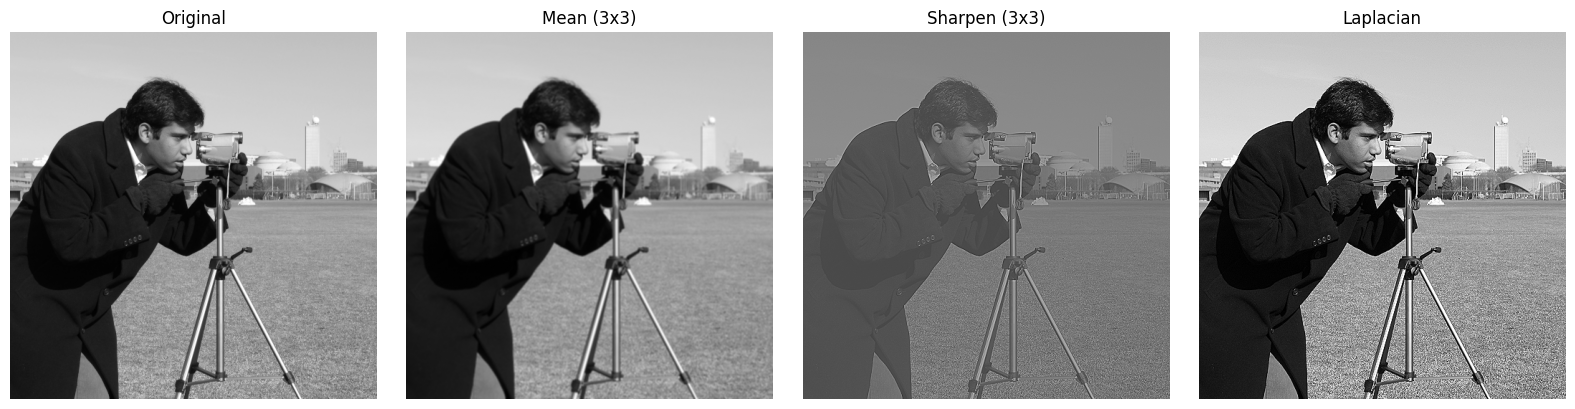

In [3]:
# Vamos pegar alguns kernels da aula
meanK3x3 = np.ones((3, 3), dtype=np.float64) / 9.0

sharpenK3x3 = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]], dtype=np.float64)

laplacianK3x3 = np.array([[ 0,  1,  0],
                         [ 1, -4,  1],
                         [ 0,  1,  0]], dtype=np.float64)

def convolveImage(img, kernel, boundary='symm'):
    """Convolucao 2D de uma imagem em nivel de cinza."""
    res = convolve2d(img, kernel, mode='same', boundary=boundary)
    return res

resMedia = convolveImage(camera, meanK3x3)

resSharpened = convolveImage(camera, sharpenK3x3)

resLaplacian = convolveImage(camera, laplacianK3x3)
resLaplacian = np.clip(camera - 0.7 * resLaplacian, 0, 1)


show_images(
    [camera, resMedia, resSharpened, resLaplacian],
    titles=["Original", "Mean (3x3)", "Sharpen (3x3)", "Laplacian"],
    cmap='gray',
    figsize=(16, 4)
)


### Convolução com loops

Igual ao slide da aula

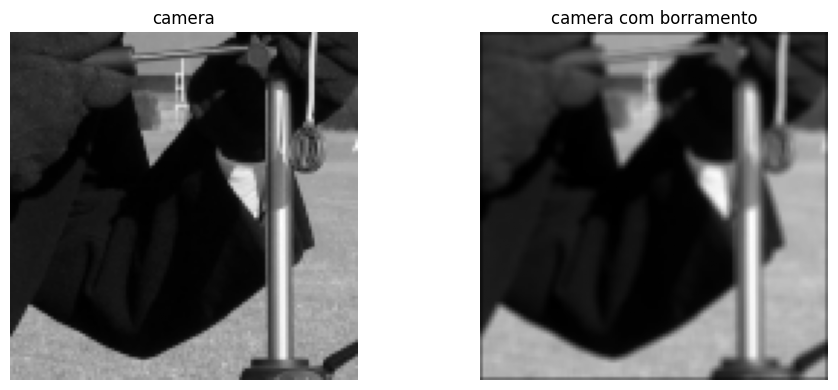

In [4]:
def conv2dWLoop(img, kernel):
    """Convolucao com (zero padding). O kernel precisa ter lados ímpares."""
    # Mudando os tipos para usar numpy
    img = img.astype(np.float64)
    k = kernel.astype(np.float64)
    # Tomando as dimensoes e verificando se o kernel tem as dimensoes corretas
    kh, kw = k.shape
    assert (kh % 2 == 1) and (kw % 2 == 1)
    # zero-padding
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    outImage = np.zeros_like(img, dtype=np.float64)
    # espelhando o kernel para fazer uma convolucao de verdade
    kernelV = np.flipud(np.fliplr(k))
    H, W = img.shape
    for i in range(H):
        for j in range(W):
            patch = padded[i:i+kh, j:j+kw]
            outImage[i, j] = np.sum(patch * kernelV)
    return outImage

cameraSmall = camera[200:320, 200:320]
resMeanCamera = conv2dWLoop(cameraSmall, meanK3x3)

show_images(
    [cameraSmall, resMeanCamera],
    titles=["camera", "camera com borramento"],
    cmap='gray',
    figsize=(10, 4)
)


## Prewitt (realce de bordas)

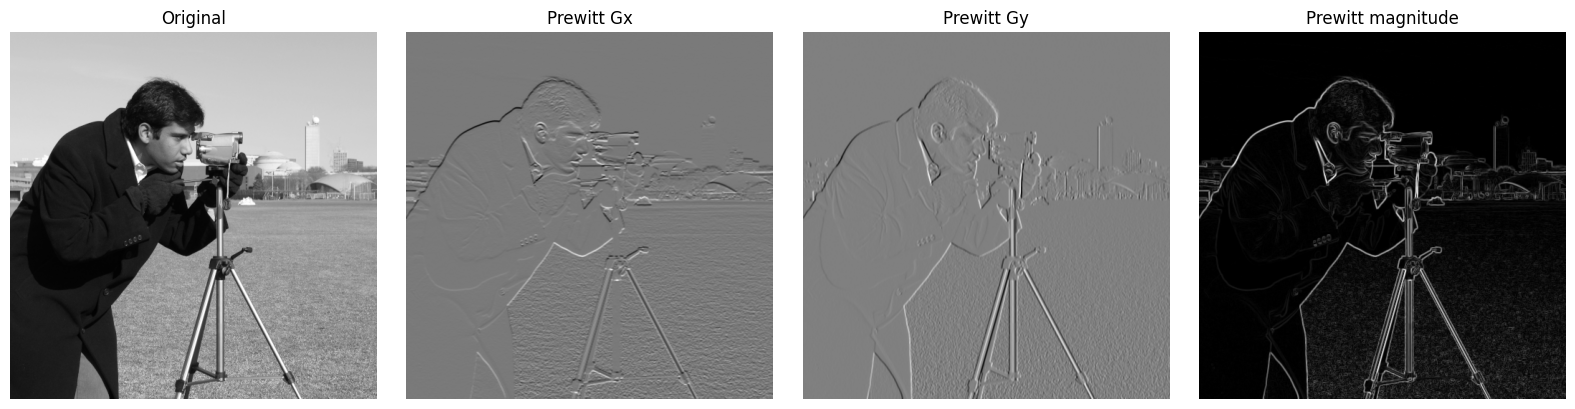

In [5]:
gx = prewitt_h(camera)
gy = prewitt_v(camera)
mag = grad_magnitude(gx, gy)

show_images(
    [camera, gx, gy, normalize01(mag)],
    titles=["Original", "Prewitt Gx", "Prewitt Gy", "Prewitt magnitude"],
    cmap='gray',
    figsize=(16, 4)
)


## Roberts (realce de bordas)

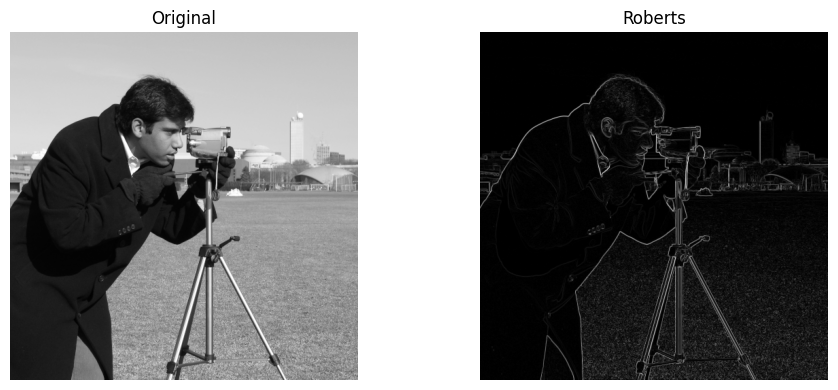

In [7]:
resRoberts = roberts(camera)

show_images(
    [camera, normalize01(resRoberts)],
    titles=["Original", "Roberts"],
    cmap='gray',
    figsize=(10, 4)
)

## Exercícios extras

1. **Convolução**
   - Experimente um filtro da média com kernel 5×5 e compare com o 3×3.
   - Experimente o filtro Gaussiano com a função `skimage.filters.gaussian` e compare.

2. **Prewitt/Roberts**
   - Aplique os filtros de Prewitt e Roberts e, depois, faça aplique um threshold para conseguir as bordas binarizadas.
   - Adicione ruído e compare a robustez.

In [8]:
from google.colab import files
from skimage.io import imread
from skimage.color import rgb2gray
import numpy as np

uploaded = files.upload()

imagens = []

for nome_arquivo in uploaded.keys():
    img = imread(nome_arquivo)

    # Converte para tons de cinza se estiver em RGB
    if len(img.shape) == 3:
        img = rgb2gray(img)

    imagens.append(img)

print(f"{len(imagens)} imagens carregadas com sucesso.")


Saving sandalia2_3.jpg to sandalia2_3.jpg
Saving sandalia2_2.jpg to sandalia2_2.jpg
Saving sandalia2_1.jpg to sandalia2_1.jpg
Saving sandalia1_3.jpg to sandalia1_3.jpg
Saving sandalia1_1.jpg to sandalia1_1.jpg
Saving sandalia1_2.jpg to sandalia1_2.jpg
Saving tenis1_1.jpg to tenis1_1.jpg
Saving tenis1_2.jpg to tenis1_2.jpg
Saving tenis1_3.jpg to tenis1_3.jpg
Saving tenis2_1.jpg to tenis2_1.jpg
Saving tenis2_2.jpg to tenis2_2.jpg
Saving tenis2_3.jpg to tenis2_3.jpg
12 imagens carregadas com sucesso.


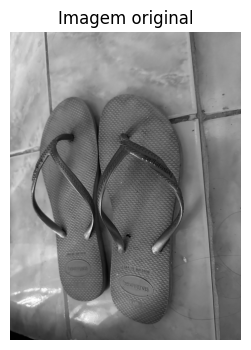

In [9]:
plt.figure(figsize=(4,4))
plt.imshow(imagens[0], cmap='gray')
plt.title("Imagem original")
plt.axis('off')
plt.show()

In [10]:
# Definição dos filtros de média (3x3 e 5x5)
filtro_media_3 = np.ones((3,3)) / 9
filtro_media_5 = np.ones((5,5)) / 25

In [11]:
# Função de convolução 2D
def conv2d(imagem, kernel):
    h, w = imagem.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2

    imagem_pad = np.pad(imagem, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    resultado = np.zeros_like(imagem)

    for i in range(h):
        for j in range(w):
            regiao = imagem_pad[i:i+kh, j:j+kw]
            resultado[i, j] = np.sum(regiao * kernel)

    return resultado

In [14]:
# Aplicando filtros de suavização
img = imagens[0]

media3 = conv2d(img, filtro_media_3)
media5 = conv2d(img, filtro_media_5)
gauss = gaussian(img, sigma=1)

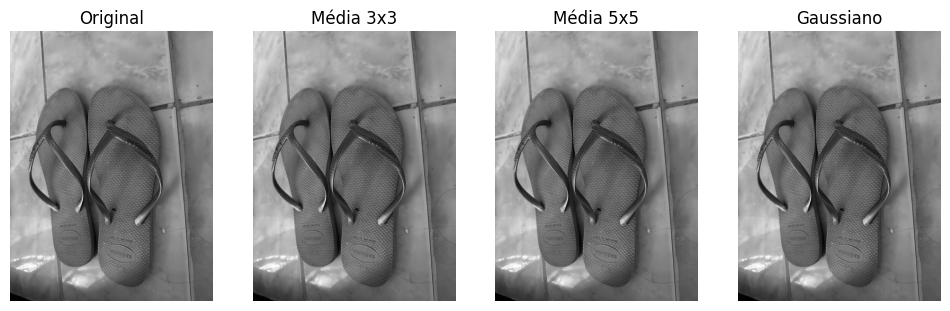

In [18]:
# Comparação visual dos filtros
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(media3, cmap='gray')
plt.title("Média 3x3")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(media5, cmap='gray')
plt.title("Média 5x5")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(gauss, cmap='gray')
plt.title("Gaussiano")
plt.axis('off')

plt.show()

In [16]:
# Filtros de borda: Prewitt e Roberts

prewitt_x = prewitt_h(img)
prewitt_y = prewitt_v(img)
prewitt_mag = np.sqrt(prewitt_x**2 + prewitt_y**2)

roberts_edge = roberts(img)

In [20]:
# Binarização automática (Otsu)

th_prewitt = threshold_otsu(prewitt_mag)
prewitt_bin = prewitt_mag > th_prewitt

th_roberts = threshold_otsu(roberts_edge)
roberts_bin = roberts_edge > th_roberts

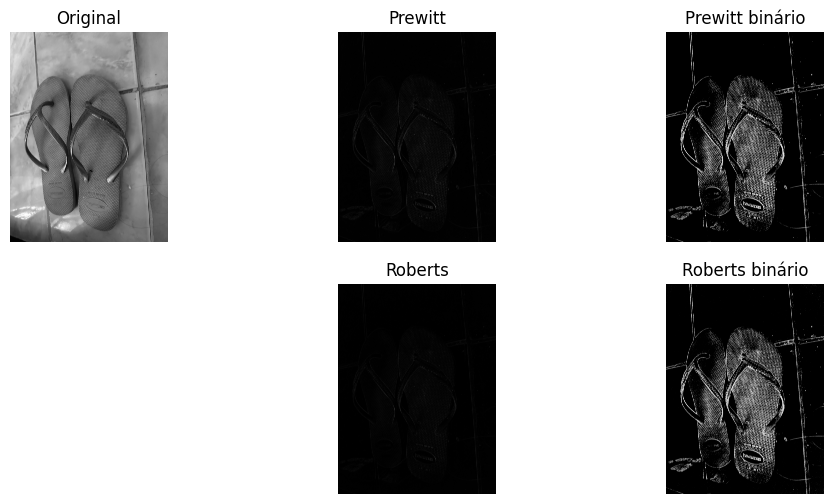

In [21]:
# Visualização das bordas
plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(prewitt_mag, cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(prewitt_bin, cmap='gray')
plt.title("Prewitt binário")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(roberts_edge, cmap='gray')
plt.title("Roberts")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(roberts_bin, cmap='gray')
plt.title("Roberts binário")
plt.axis('off')

plt.show()

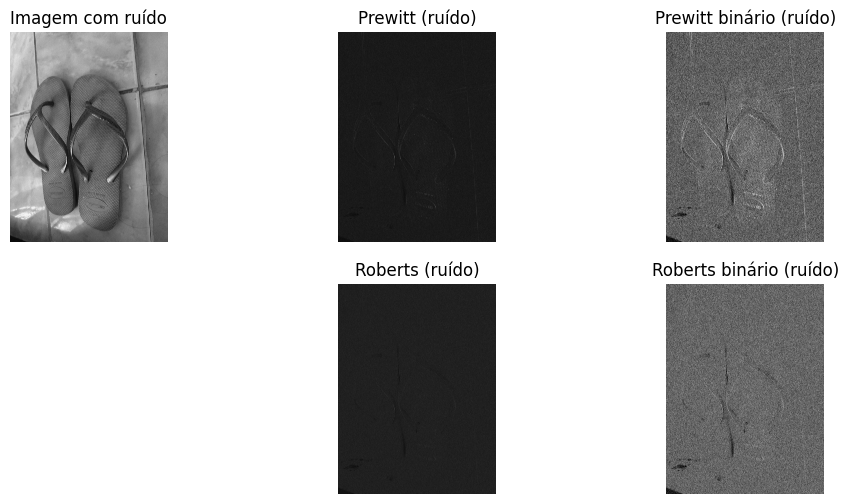

In [24]:
# Teste com ruído
img_ruido = random_noise(img, mode='gaussian', var=0.01)

prewitt_ruido = np.sqrt(prewitt_h(img_ruido)**2 + prewitt_v(img_ruido)**2)
roberts_ruido = roberts(img_ruido)

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img_ruido, cmap='gray')
plt.title("Imagem com ruído")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(prewitt_ruido, cmap='gray')
plt.title("Prewitt (ruído)")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(prewitt_ruido > threshold_otsu(prewitt_ruido), cmap='gray')
plt.title("Prewitt binário (ruído)")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(roberts_ruido, cmap='gray')
plt.title("Roberts (ruído)")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(roberts_ruido > threshold_otsu(roberts_ruido), cmap='gray')
plt.title("Roberts binário (ruído)")
plt.axis('off')

plt.show()